Walk-Forward Validation

- Instead of one fixed 80/20 split, retrain the model on a rolling window and predict the next chunk
- Simulates how a live trading system would operate: retrain periodically with recent data
- Gives multiple out-of-sample tests across different market conditions
- More realistic (and usually lower) accuracy estimate than a single split
- Compare walk-forward vs single split to see how much the single split overstates performance

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/Users/giovanafalcao/Desktop/Projects/trading-analytics")
from utils import yfinance_fix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

TICKER = "AAPL"
INTERVAL = "1d"
PERIOD = "max"
LOOKBACK = 10000
TARGET_SHIFT = 1
THRESHOLD = 0.55
TRAIN_WINDOW = 504
STEP = 63

FEATURES = ["momentum_21d", "momentum_252_21d", "vol_ratio", "hv_20", "illiquidity", "autocorr_20",
            "RSI", "MACD_HIST", "ATR", "BB_Percent", "MFI"]

# Fetch data
df = yf.download(TICKER, session=yfinance_fix.chrome_session, interval=INTERVAL, period=PERIOD)
df.columns = df.columns.get_level_values(0)
df = df.iloc[-LOOKBACK:, :]

# Compute features
log_returns = np.log(df["Close"] / df["Close"].shift(1))
df["momentum_21d"] = df["Close"].pct_change(21)
df["momentum_252_21d"] = df["Close"].pct_change(252) - df["Close"].pct_change(21)
df["vol_ratio"] = log_returns.rolling(5).std() / log_returns.rolling(20).std()
df["hv_20"] = log_returns.rolling(20).std() * np.sqrt(252)
df["illiquidity"] = (log_returns.abs() / df["Volume"]).rolling(20).mean()
df["autocorr_20"] = log_returns.rolling(20).apply(lambda x: x.autocorr(lag=1))

price_change = df["Close"].diff()
gain = price_change.where(price_change > 0, 0)
loss = -price_change.where(price_change < 0, 0)
df["RSI"] = 100 - (100 / (1 + gain.rolling(14).mean() / loss.rolling(14).mean()))
ema_fast = df["Close"].ewm(span=12).mean()
ema_slow = df["Close"].ewm(span=26).mean()
macd_line = ema_fast - ema_slow
df["MACD_HIST"] = macd_line - macd_line.ewm(span=9).mean()
high_low = df["High"] - df["Low"]
high_close = (df["High"] - df["Close"].shift(1)).abs()
low_close = (df["Low"] - df["Close"].shift(1)).abs()
df["ATR"] = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1).rolling(14).mean()
sma = df["Close"].rolling(20).mean()
rolling_std = df["Close"].rolling(20).std()
df["BB_Percent"] = (df["Close"] - (sma - 2 * rolling_std)) / (4 * rolling_std)
typical = (df["High"] + df["Low"] + df["Close"]) / 3
mf = typical * df["Volume"]
delta = typical.diff()
df["MFI"] = 100 - (100 / (1 + mf.where(delta > 0, 0).rolling(14).sum() / mf.where(delta < 0, 0).rolling(14).sum()))

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES)
print(f"Rows after cleaning: {len(df)}")

[*********************100%***********************]  1 of 1 completed


Rows after cleaning: 9748


Step 1: Walk-Forward Loop

Rolling window: train on TRAIN_WINDOW bars, predict next STEP bars, slide forward.
Each fold: build target, scale, train, predict, record metrics.
This is the same logic as utils/signals.py walk_forward_ml_strategy().

In [7]:
def walk_forward(df, model_class, model_kwargs, train_window=TRAIN_WINDOW, step=STEP):
    signals = pd.Series(0, index=df.index, dtype=int)
    fold_results = []
    n = len(df)
    pos = 0

    while pos + train_window + step <= n:
        train_raw = df.iloc[pos: pos + train_window - TARGET_SHIFT].copy()
        test = df.iloc[pos + train_window: pos + train_window + step]

        train_raw["Target"] = (train_raw["Close"].shift(-TARGET_SHIFT) > train_raw["Close"]).astype(int)
        train_raw = train_raw.iloc[:-TARGET_SHIFT]

        X_train = train_raw[FEATURES].replace([np.inf, -np.inf], np.nan).dropna()
        y_train = train_raw["Target"].loc[X_train.index]
        X_test = test[FEATURES].replace([np.inf, -np.inf], np.nan).dropna()

        if len(X_train) < 30 or len(y_train.unique()) < 2 or len(X_test) == 0:
            pos += step
            continue

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        model = model_class(**model_kwargs)
        model.fit(X_train_s, y_train)
        proba = model.predict_proba(X_test_s)[:, 1]

        fold_sigs = np.where(proba > THRESHOLD, 1, np.where(proba < (1 - THRESHOLD), -1, 0))
        signals.loc[X_test.index] = fold_sigs

        test_target = (df["Close"].shift(-TARGET_SHIFT) > df["Close"]).astype(int)
        y_test = test_target.loc[X_test.index].dropna()
        common = y_test.index.intersection(X_test.index)

        if len(common) > 0:
            y_t = y_test.loc[common]
            preds = (proba[X_test.index.isin(common)] > 0.5).astype(int)
            fold_entry = {
                "fold": len(fold_results) + 1,
                "train_start": df.index[pos].strftime("%Y-%m-%d"),
                "test_start": test.index[0].strftime("%Y-%m-%d"),
                "test_end": X_test.index[-1].strftime("%Y-%m-%d"),
                "n_train": len(X_train),
                "n_test": len(X_test),
                "accuracy": accuracy_score(y_t, preds),
                "f1": f1_score(y_t, preds, zero_division=0),
            }
            try:
                fold_entry["roc_auc"] = roc_auc_score(y_t, proba[X_test.index.isin(common)]) if len(y_t.unique()) > 1 else None
            except Exception:
                fold_entry["roc_auc"] = None
            fold_results.append(fold_entry)

        pos += step

    return signals.shift(1).fillna(0).astype(int), fold_results

wf_signals, wf_folds = walk_forward(df, LogisticRegression, {"max_iter": 1000, "random_state": 42})

folds_df = pd.DataFrame(wf_folds)
print(f"Number of folds: {len(wf_folds)}")
print(f"\nPer-fold results:")
print(folds_df[["fold", "train_start", "test_start", "test_end", "accuracy", "f1"]].to_string(index=False))
print(f"\nMean accuracy: {folds_df['accuracy'].mean():.4f} (+/- {folds_df['accuracy'].std():.4f})")
print(f"Mean F1:       {folds_df['f1'].mean():.4f}")

Number of folds: 146

Per-fold results:
 fold train_start test_start   test_end  accuracy       f1
    1  1987-08-07 1989-08-04 1989-11-01  0.428571 0.333333
    2  1987-11-05 1989-11-02 1990-02-01  0.555556 0.416667
    3  1988-02-05 1990-02-02 1990-05-03  0.539683 0.452830
    4  1988-05-06 1990-05-04 1990-08-02  0.444444 0.363636
    5  1988-08-05 1990-08-03 1990-10-31  0.730159 0.370370
    6  1988-11-03 1990-11-01 1991-01-31  0.476190 0.352941
    7  1989-02-03 1991-02-01 1991-05-02  0.523810 0.062500
    8  1989-05-05 1991-05-03 1991-08-01  0.587302 0.315789
    9  1989-08-04 1991-08-02 1991-10-30  0.492063 0.304348
   10  1989-11-02 1991-10-31 1992-01-30  0.492063 0.333333
   11  1990-02-02 1992-01-31 1992-04-30  0.571429 0.129032
   12  1990-05-04 1992-05-01 1992-07-30  0.412698 0.212766
   13  1990-08-03 1992-07-31 1992-10-28  0.603175 0.390244
   14  1990-11-01 1992-10-29 1993-01-28  0.603175 0.528302
   15  1991-02-01 1993-01-29 1993-04-29  0.492063 0.111111
   16  1991-05-0

Step 2: Visualize fold accuracy + timeline

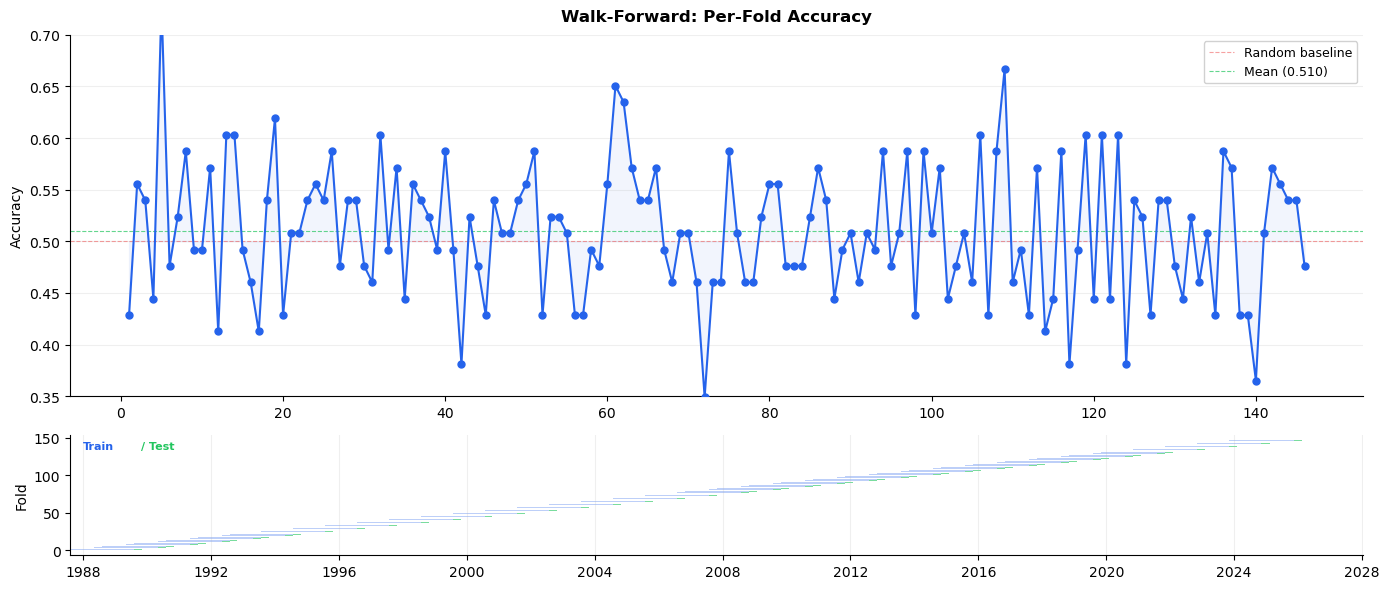

In [8]:
COLOR_BLUE = "#2563eb"
COLOR_GREEN = "#22c55e"
COLOR_RED = "#ef4444"
COLOR_GRAY = "#6b7280"

fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={"height_ratios": [3, 1]})
fig.patch.set_facecolor("white")

# Top: accuracy per fold
axes[0].plot(folds_df["fold"], folds_df["accuracy"], marker="o", color=COLOR_BLUE, linewidth=1.5, markersize=5, zorder=3)
axes[0].fill_between(folds_df["fold"], 0.5, folds_df["accuracy"], alpha=0.06, color=COLOR_BLUE)
axes[0].axhline(0.5, color=COLOR_RED, linewidth=0.8, linestyle="--", alpha=0.5, label="Random baseline")
axes[0].axhline(folds_df["accuracy"].mean(), color=COLOR_GREEN, linewidth=0.8, linestyle="--", alpha=0.7, label=f"Mean ({folds_df['accuracy'].mean():.3f})")
axes[0].set_ylabel("Accuracy", fontsize=10)
axes[0].set_ylim(0.35, 0.70)
axes[0].legend(fontsize=9, loc="upper right", framealpha=0.9)
axes[0].set_title("Walk-Forward: Per-Fold Accuracy", fontsize=12, fontweight="bold", pad=10)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", alpha=0.2)

# Bottom: train/test timeline using actual dates
for _, row in folds_df.iterrows():
    ts = pd.Timestamp(row["train_start"])
    te = pd.Timestamp(row["test_start"])
    tend = pd.Timestamp(row["test_end"])
    axes[1].barh(row["fold"], (te - ts).days, left=ts, color=COLOR_BLUE, alpha=0.3, height=0.5, edgecolor="none")
    axes[1].barh(row["fold"], (tend - te).days, left=te, color=COLOR_GREEN, alpha=0.6, height=0.5, edgecolor="none")

axes[1].set_ylabel("Fold", fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="x", alpha=0.2)
axes[1].text(0.01, 0.88, "Train", transform=axes[1].transAxes, fontsize=8, color=COLOR_BLUE, fontweight="bold")
axes[1].text(0.055, 0.88, "/ Test", transform=axes[1].transAxes, fontsize=8, color=COLOR_GREEN, fontweight="bold")

plt.tight_layout()
plt.show()

Step 3: Walk-Forward vs Single Split

In [9]:
# Single split baseline
split_idx = int(len(df) * 0.8)
train_ss = df.iloc[:split_idx - TARGET_SHIFT].copy()
test_ss = df.iloc[split_idx:].copy()

train_ss["Target"] = (train_ss["Close"].shift(-TARGET_SHIFT) > train_ss["Close"]).astype(int)
train_ss = train_ss.iloc[:-TARGET_SHIFT]
test_ss["Target"] = (test_ss["Close"].shift(-TARGET_SHIFT) > test_ss["Close"]).astype(int)
test_ss = test_ss.iloc[:-TARGET_SHIFT]

scaler = StandardScaler()
X_tr = scaler.fit_transform(train_ss[FEATURES])
X_te = scaler.transform(test_ss[FEATURES])

model_ss = LogisticRegression(max_iter=1000, random_state=42)
model_ss.fit(X_tr, train_ss["Target"])
ss_preds = model_ss.predict(X_te)
ss_accuracy = accuracy_score(test_ss["Target"], ss_preds)

print(f"Single Split accuracy:      {ss_accuracy:.4f}")
print(f"Walk-Forward mean accuracy: {folds_df['accuracy'].mean():.4f}")
print(f"Difference:                 {ss_accuracy - folds_df['accuracy'].mean():+.4f}")
print(f"\nWalk-Forward accuracy std:  {folds_df['accuracy'].std():.4f}")
print(f"Walk-Forward min fold:      {folds_df['accuracy'].min():.4f}")
print(f"Walk-Forward max fold:      {folds_df['accuracy'].max():.4f}")

Single Split accuracy:      0.4900
Walk-Forward mean accuracy: 0.5099
Difference:                 -0.0199

Walk-Forward accuracy std:  0.0647
Walk-Forward min fold:      0.3492
Walk-Forward max fold:      0.7302


Step 4: LogReg vs Random Forest — Walk-Forward Comparison

Model                  Mean Acc      Std    Mean F1
LogReg                   0.5099   0.0647     0.4774
Random Forest            0.5020   0.0600     0.4785


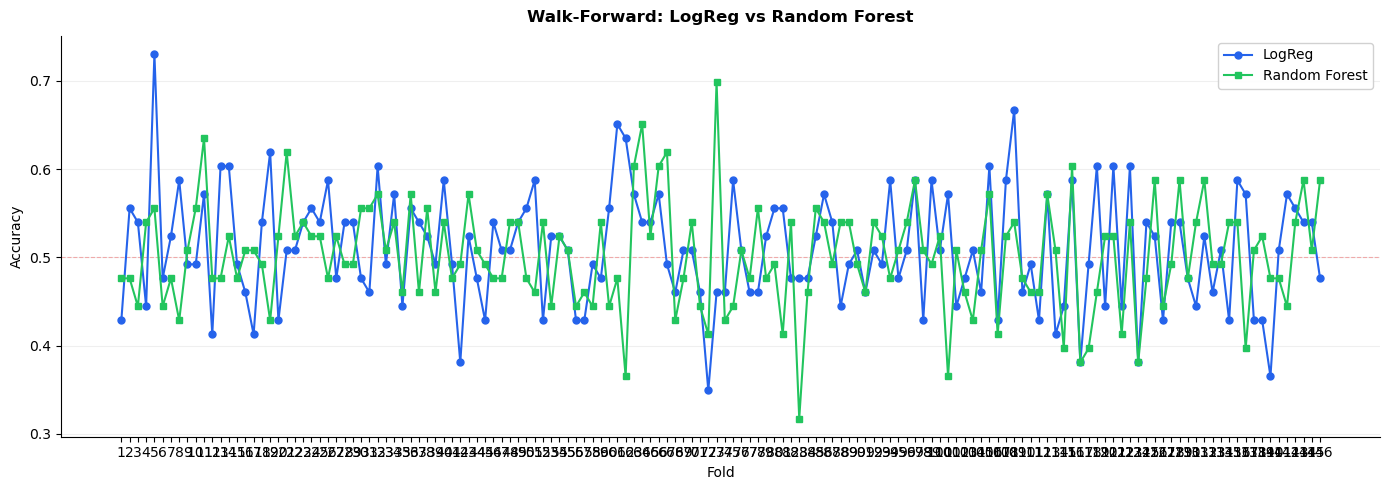

In [10]:
wf_signals_rf, wf_folds_rf = walk_forward(df, RandomForestClassifier, {"n_estimators": 100, "random_state": 42})
folds_rf = pd.DataFrame(wf_folds_rf)

print(f"{'Model':<20s} {'Mean Acc':>10s} {'Std':>8s} {'Mean F1':>10s}")
print(f"{'LogReg':<20s} {folds_df['accuracy'].mean():>10.4f} {folds_df['accuracy'].std():>8.4f} {folds_df['f1'].mean():>10.4f}")
print(f"{'Random Forest':<20s} {folds_rf['accuracy'].mean():>10.4f} {folds_rf['accuracy'].std():>8.4f} {folds_rf['f1'].mean():>10.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("white")
x = np.arange(len(folds_df))

ax.plot(x, folds_df["accuracy"], marker="o", color=COLOR_BLUE, linewidth=1.5, markersize=5, label="LogReg", zorder=3)
ax.plot(x, folds_rf["accuracy"], marker="s", color=COLOR_GREEN, linewidth=1.5, markersize=5, label="Random Forest", zorder=3)
ax.axhline(0.5, color=COLOR_RED, linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Fold", fontsize=10)
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_title("Walk-Forward: LogReg vs Random Forest", fontsize=12, fontweight="bold", pad=10)
ax.set_xticks(x)
ax.set_xticklabels(folds_df["fold"])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()